In [ ]:
# Online Food Delivery Customer Analysis

## Python, SQL and Statistical Analysis

### Project Overview

This project analyses customer behaviour in an online food delivery dataset. The analysis uses Python, pandas, data visualization, statistical testing and DuckDB SQL to identify patterns associated with online food ordering.

### Objectives

- Analyse customer demographics
- Examine online food ordering behaviour
- Identify customer segments with different ordering rates
- Test associations between customer characteristics and ordering behaviour
- Use SQL to answer business questions
- Develop actionable business recommendations

In [ ]:
### Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- SciPy
- DuckDB
- SQL
- Jupyter Notebook

In [1]:
pip install pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

os.getcwd()

'C:\\Users\\flex zone'

In [ ]:
##3. load data set

In [4]:
import pandas as pd
df = pd.read_csv("online food delivery dataset.csv")

In [ ]:
##4. data understanding

In [5]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [6]:
df.info()
df.shape
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    str    
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    str    
 12  Feedback                    388 non-null    str    
 13  Unnamed: 13                 388 non-null    st

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [ ]:
##5. data cleaning

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
383     True
384     True
385     True
386    False
387     True
Length: 388, dtype: bool

In [9]:
df[df.duplicated()]

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
43,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
48,23,Female,Single,Student,No Income,Graduate,3,Regular,12.9820,77.6256,560008,Yes,Negative,Yes
49,22,Female,Single,Student,10001 to 25000,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
52,24,Male,Single,Student,No Income,Post Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
60,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,560042,Yes,Positive,Yes
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [10]:
df=df.drop_duplicates()

In [11]:
df[df.duplicated()]

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13


In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

In [12]:
df["Unnamed: 13"].value_counts(dropna=False)

Unnamed: 13
Yes    217
No      68
Name: count, dtype: int64

In [13]:
df["Unnamed: 13"].head(10)

0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
5    Yes
6    Yes
7    Yes
8    Yes
9    Yes
Name: Unnamed: 13, dtype: str

In [15]:
df.columns.tolist()

['Age',
 'Gender',
 'Marital Status',
 'Occupation',
 'Monthly Income',
 'Educational Qualifications',
 'Family size',
 'Customer Type',
 'latitude',
 'longitude',
 'Pin code',
 'Output',
 'Feedback',
 'Unnamed: 13']

In [17]:
df = df.drop(columns=["Unnamed: 13"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 285 entries, 0 to 386
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         285 non-null    int64  
 1   Gender                      285 non-null    str    
 2   Marital Status              285 non-null    str    
 3   Occupation                  285 non-null    str    
 4   Monthly Income              285 non-null    str    
 5   Educational Qualifications  285 non-null    str    
 6   Family size                 285 non-null    int64  
 7   Customer Type               285 non-null    str    
 8   latitude                    285 non-null    float64
 9   longitude                   285 non-null    float64
 10  Pin code                    285 non-null    int64  
 11  Output                      285 non-null    str    
 12  Feedback                    285 non-null    str    
dtypes: float64(2), int64(3), str(8)
memory usage: 48.0 

In [22]:
df["Gender"].value_counts()

Gender
Male      164
Female    121
Name: count, dtype: int64

In [24]:
df["Feedback"].value_counts()

Feedback
Positive     231
Negative      54
Name: count, dtype: int64

In [25]:
df["Marital Status"].value_counts()

Marital Status
Single               189
Married               87
Prefer not to say      9
Name: count, dtype: int64

In [26]:
df["Occupation"].value_counts()

Occupation
Student           144
Employee           94
Self Employeed     38
House wife          9
Name: count, dtype: int64

In [27]:
df["Educational Qualifications"].value_counts()

Educational Qualifications
Graduate         126
Post Graduate    125
Ph.D              21
School            11
Uneducated         2
Name: count, dtype: int64

In [28]:
df["Customer Type"].value_counts()

Customer Type
Regular     162
Frequent    105
New          18
Name: count, dtype: int64

In [30]:
df.dtypes

Age                             int64
Gender                            str
Marital Status                    str
Occupation                        str
Monthly Income                    str
Educational Qualifications        str
Family size                     int64
Customer Type                     str
latitude                      float64
longitude                     float64
Pin code                        int64
Output                            str
Feedback                          str
dtype: object

In [31]:
df[
    [
        "Age",
        "Monthly Income",
        "Family size",
        "longitude",
        "latitude",
        "Pin code"
    ]
 ].describe()

,Age,Family size,longitude,latitude,Pin code
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,24.677193,3.270175,77.597593,12.973429,560037.280702
std,3.040977,1.361178,0.053557,0.043964,30.738306
min,18.000000,1.000000,77.484200,12.865200,560001.000000
25%,23.000000,2.000000,77.563500,12.943800,560010.000000
50%,24.000000,3.000000,77.587700,12.977000,560028.000000
75%,26.000000,4.000000,77.622700,12.998000,560066.000000
max,33.000000,6.000000,77.758200,13.102000,560109.000000


In [33]:
#standardizing columns 
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [35]:
df.head(0)

,age,gender,marital_status,occupation,monthly_income,educational_qualifications,family_size,customer_type,latitude,longitude,pin_code,output,feedback


In [36]:
df.head(1)

,age,gender,marital_status,occupation,monthly_income,educational_qualifications,family_size,customer_type,latitude,longitude,pin_code,output,feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive


In [37]:
df["age"].sort_values().head(20)

109    18
280    19
196    19
134    19
133    19
0      20
252    20
152    20
169    20
159    20
205    20
289    20
271    21
245    21
24     21
374    21
262    21
220    21
160    21
212    21
Name: age, dtype: int64

In [38]:
df["age"].sort_values(ascending=False).head(20)

137    33
123    32
37     32
118    32
131    32
99     32
157    32
148    32
223    32
215    32
229    32
240    32
184    32
58     31
116    31
192    31
189    31
218    31
363    31
248    31
Name: age, dtype: int64

In [39]:
df["age"].sort_values(ascending=False).head(20)

137    33
123    32
37     32
118    32
131    32
99     32
157    32
148    32
223    32
215    32
229    32
240    32
184    32
58     31
116    31
192    31
189    31
218    31
363    31
248    31
Name: age, dtype: int64

In [40]:
import os

print(os.getcwd())

C:\Users\flex zone


In [41]:
df.to_csv(
    "online_food_delivery_cleaned.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [42]:
os.path.exists("online_food_delivery_cleaned.csv")


True

In [43]:
df.to_csv("online_food_delivery_cleaned.csv", index=False)

In [ ]:
##6. Exploratory Data Analysis

In [44]:
df.head()

,age,gender,marital_status,occupation,monthly_income,educational_qualifications,family_size,customer_type,latitude,longitude,pin_code,output,feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive


In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 285 entries, 0 to 386
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         285 non-null    int64  
 1   gender                      285 non-null    str    
 2   marital_status              285 non-null    str    
 3   occupation                  285 non-null    str    
 4   monthly_income              285 non-null    str    
 5   educational_qualifications  285 non-null    str    
 6   family_size                 285 non-null    int64  
 7   customer_type               285 non-null    str    
 8   latitude                    285 non-null    float64
 9   longitude                   285 non-null    float64
 10  pin_code                    285 non-null    int64  
 11  output                      285 non-null    str    
 12  feedback                    285 non-null    str    
dtypes: float64(2), int64(3), str(8)
memory usage: 48.0 

In [46]:
df.shape

(285, 13)

In [47]:
df.describe()

,age,family_size,latitude,longitude,pin_code
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,24.677193,3.270175,12.973429,77.597593,560037.280702
std,3.040977,1.361178,0.043964,0.053557,30.738306
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.943800,77.563500,560010.000000
50%,24.000000,3.000000,12.977000,77.587700,560028.000000
75%,26.000000,4.000000,12.998000,77.622700,560066.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [49]:
df["age"].describe()

count    285.000000
mean      24.677193
std        3.040977
min       18.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       33.000000
Name: age, dtype: float64

In [50]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

In [51]:
df["age_group"].value_counts().sort_index()

age_group
Under 18      1
18-25       194
26-35        90
36-45         0
46-55         0
56+           0
Name: count, dtype: int64

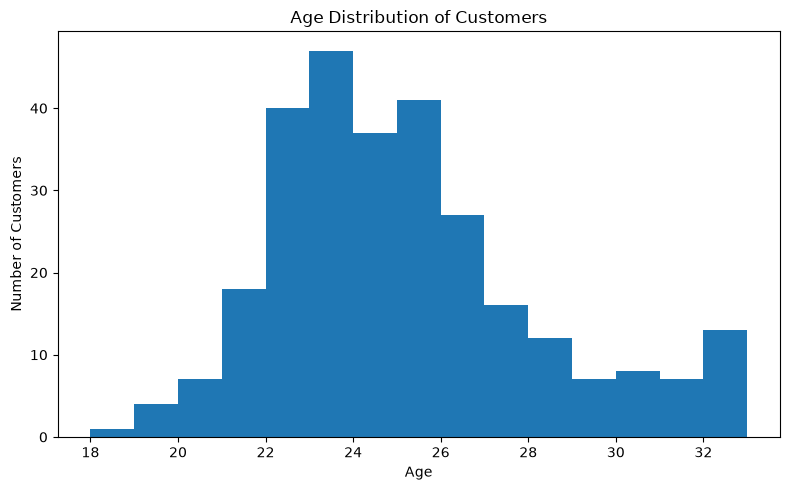

In [54]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
#gender analysis

In [55]:
gender_counts = df["gender"].value_counts()

gender_counts

gender
Male      164
Female    121
Name: count, dtype: int64

In [56]:
gender_percent = (
    df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_percent

gender
Male      57.54
Female    42.46
Name: proportion, dtype: float64

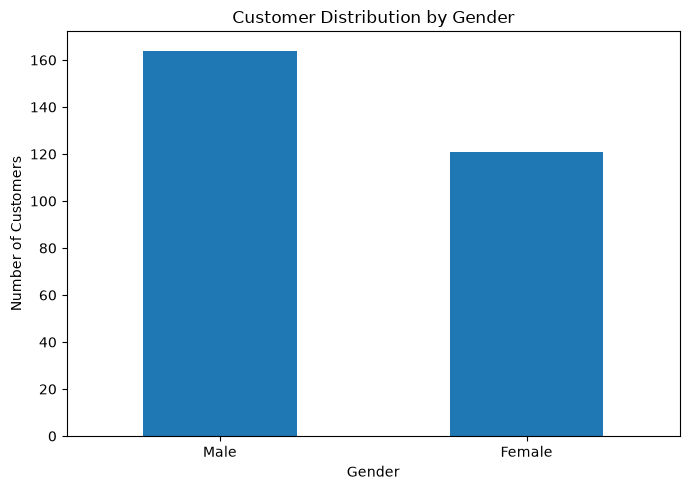

In [57]:
plt.figure(figsize=(7,5))

gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#marital status 

In [58]:
marital_counts = df["marital_status"].value_counts()

marital_counts

marital_status
Single               189
Married               87
Prefer not to say      9
Name: count, dtype: int64

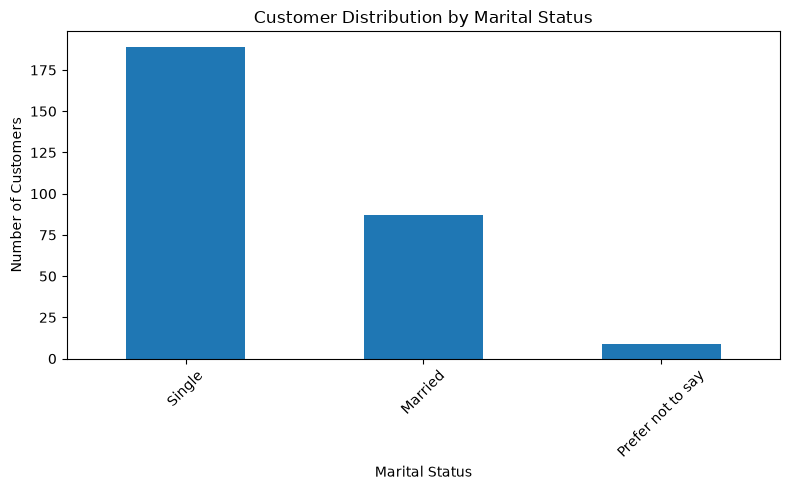

In [59]:
plt.figure(figsize=(8,5))

marital_counts.plot(kind="bar")

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [60]:
#occupational analysis

occupation_counts = df["occupation"].value_counts()

occupation_counts

occupation
Student           144
Employee           94
Self Employeed     38
House wife          9
Name: count, dtype: int64

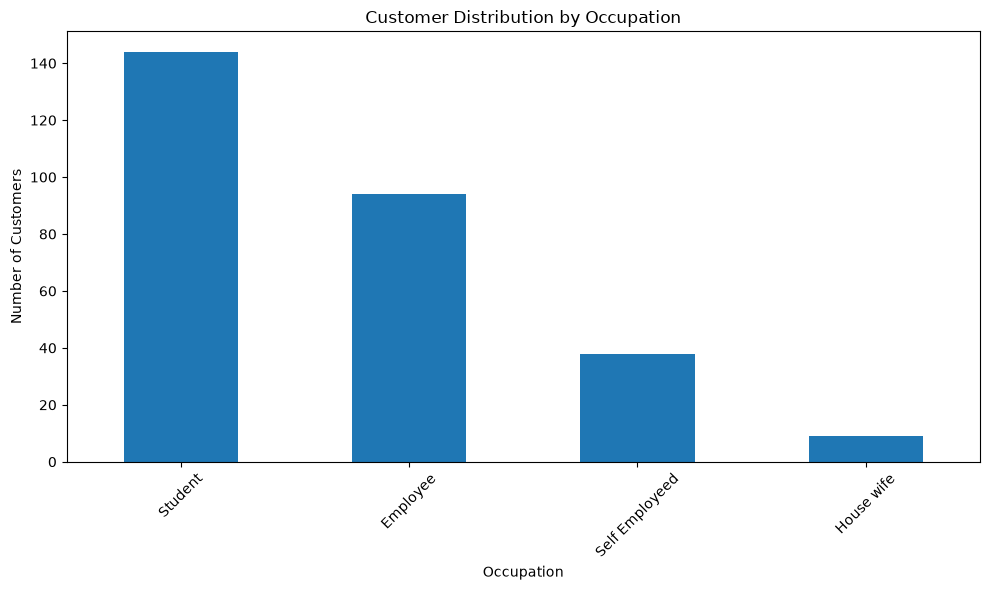

In [61]:
plt.figure(figsize=(10,6))

occupation_counts.plot(kind="bar")

plt.title("Customer Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
#Which occupation group has the largest representation?

education_counts = df["educational_qualifications"].value_counts()

education_counts

educational_qualifications
Graduate         126
Post Graduate    125
Ph.D              21
School            11
Uneducated         2
Name: count, dtype: int64

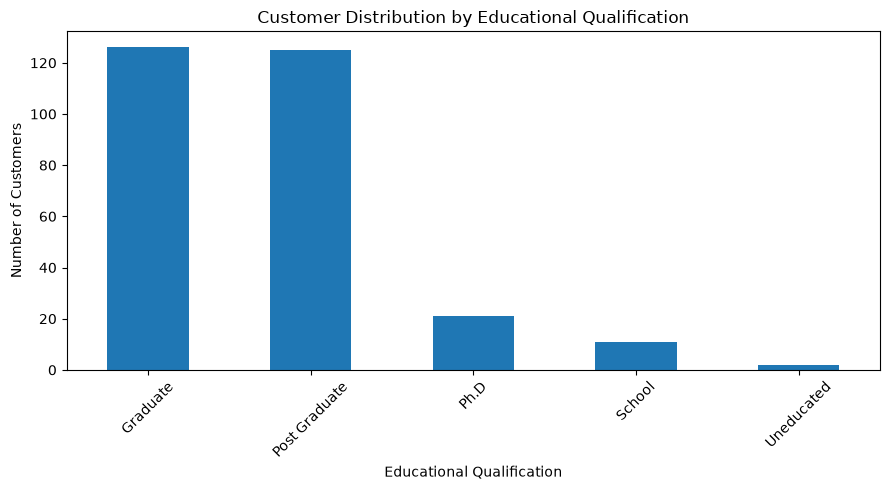

In [63]:
plt.figure(figsize=(9,5))

education_counts.plot(kind="bar")

plt.title("Customer Distribution by Educational Qualification")
plt.xlabel("Educational Qualification")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [65]:
customer_type_counts = df["customer_type"].value_counts()

customer_type_counts

customer_type
Regular     162
Frequent    105
New          18
Name: count, dtype: int64

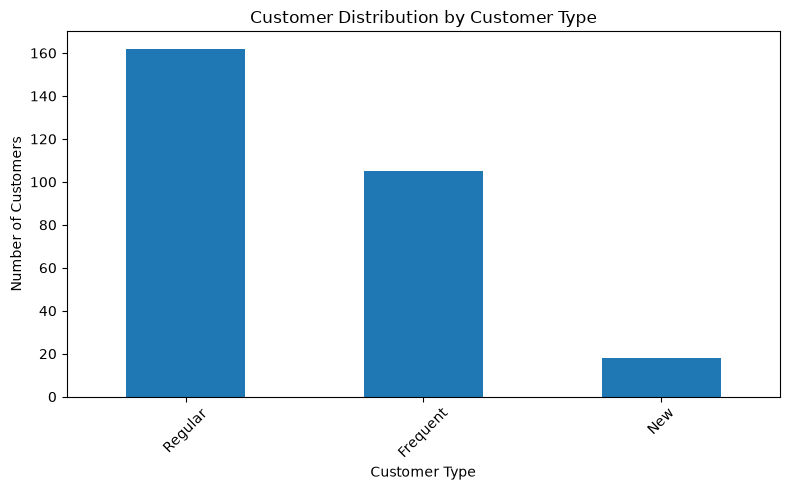

In [64]:


plt.figure(figsize=(8,5))

customer_type_counts.plot(kind="bar")

plt.title("Customer Distribution by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

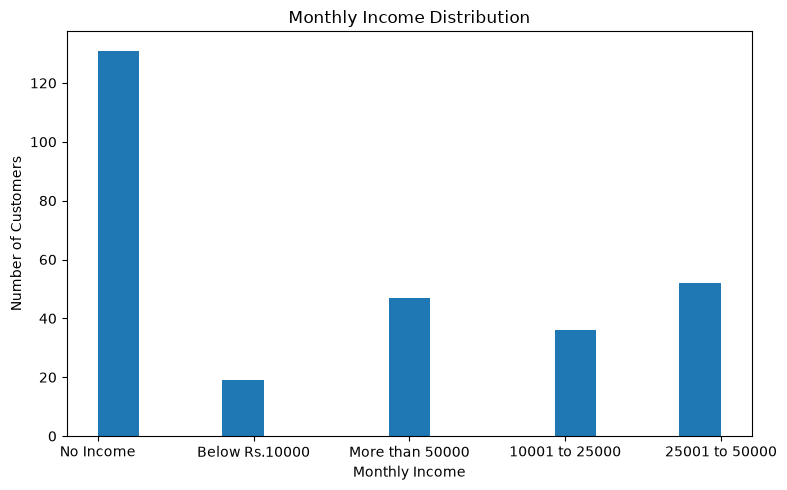

In [66]:
plt.figure(figsize=(8,5))

plt.hist(df["monthly_income"], bins=15)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
The typical income range.

Very high income values.

Whether the distribution looks concentrated or spread out.

In [67]:
df["family_size"].value_counts().sort_index()

family_size
1    18
2    75
3    87
4    45
5    37
6    23
Name: count, dtype: int64

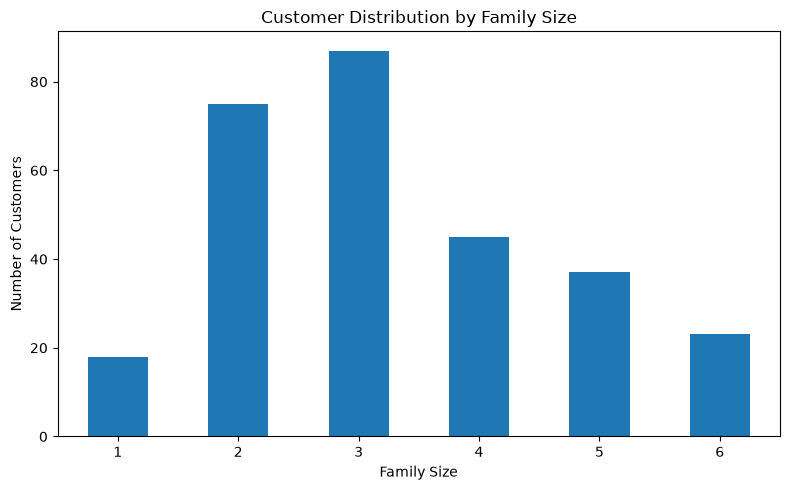

In [68]:
plt.figure(figsize=(8,5))

df["family_size"].value_counts().sort_index().plot(kind="bar")

plt.title("Customer Distribution by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [69]:
df["output"].value_counts()

output
Yes    217
No      68
Name: count, dtype: int64

In [70]:
df["output"].value_counts(normalize=True).mul(100).round(2)

output
Yes    76.14
No     23.86
Name: proportion, dtype: float64

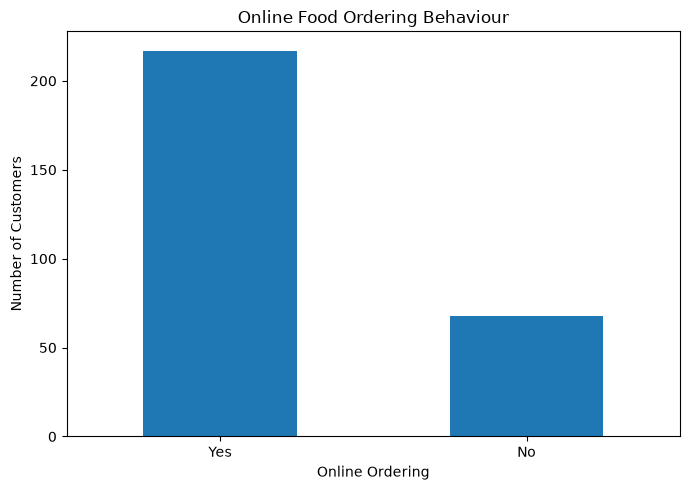

In [71]:
plt.figure(figsize=(7,5))

df["output"].value_counts().plot(kind="bar")

plt.title("Online Food Ordering Behaviour")
plt.xlabel("Online Ordering")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [72]:
gender_ordering = pd.crosstab(
    df["gender"],
    df["output"]
)

gender_ordering

output,No,Yes
gender,,
Female,31,90
Male,37,127


In [73]:
gender_ordering_percent = pd.crosstab(
    df["gender"],
    df["output"],
    normalize="index"
).mul(100).round(2)

gender_ordering_percent

output,No,Yes
gender,,
Female,25.62,74.38
Male,22.56,77.44


In [ ]:
Which gender has the higher online-ordering rate?

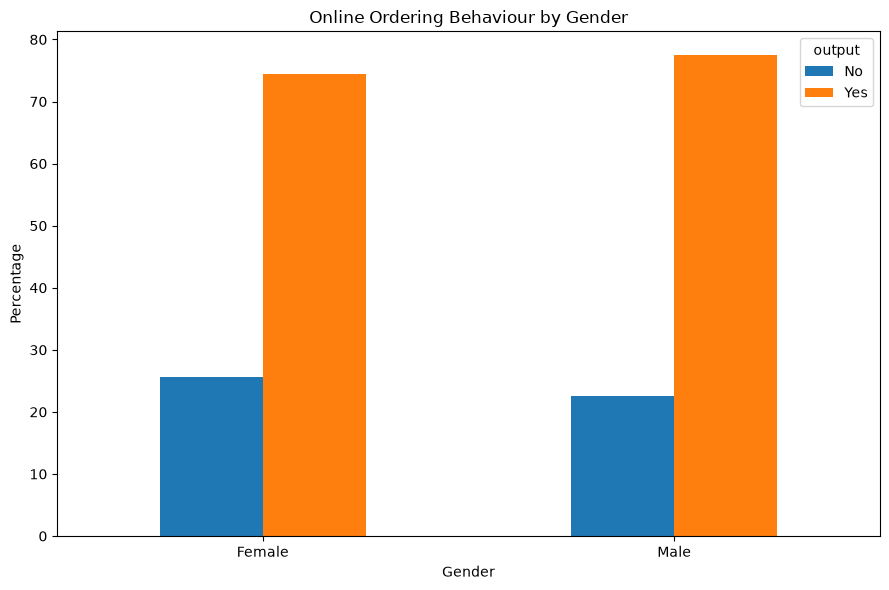

In [74]:
gender_ordering_percent.plot(
    kind="bar",
    figsize=(9,6)
)

plt.title("Online Ordering Behaviour by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [75]:
#age vs odering 
age_ordering = pd.crosstab(
    df["age_group"],
    df["output"],
    normalize="index"
).mul(100).round(2)

age_ordering

output,No,Yes
age_group,,
Under 18,0.00,100.00
18-25,14.95,85.05
26-35,43.33,56.67


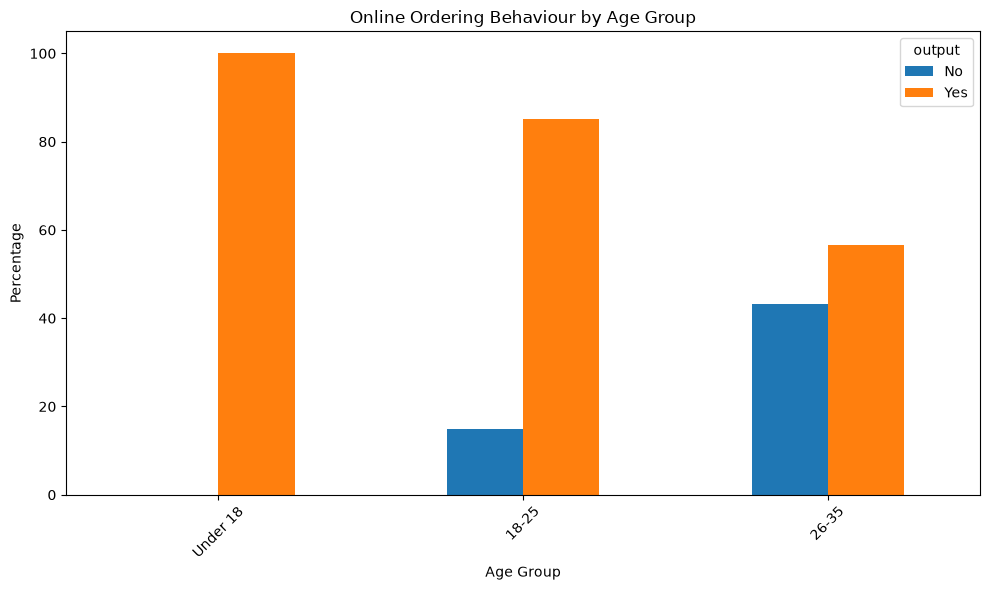

In [76]:
age_ordering.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Online Ordering Behaviour by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [77]:
#occupation vs odering 
occupation_ordering = pd.crosstab(
    df["occupation"],
    df["output"],
    normalize="index"
).mul(100).round(2)

occupation_ordering

output,No,Yes
occupation,,
Employee,36.17,63.83
House wife,22.22,77.78
Self Employeed,36.84,63.16
Student,12.50,87.50


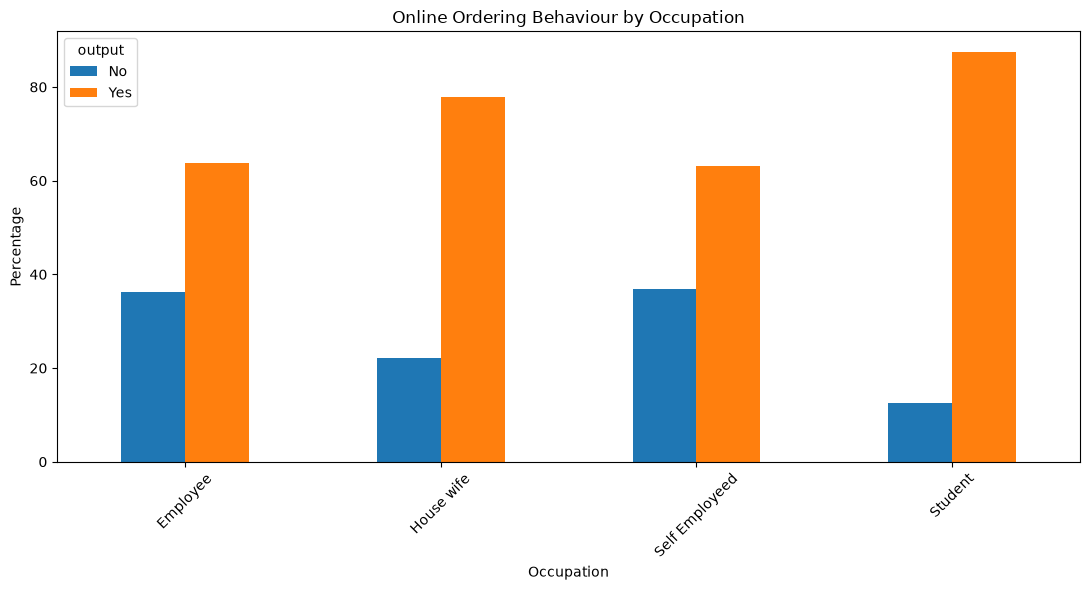

In [78]:
occupation_ordering.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Online Ordering Behaviour by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
#education vs odering 
marital_ordering = pd.crosstab(
    df["marital_status"],
    df["output"],
    normalize="index"
).mul(100).round(2)

marital_ordering

output,No,Yes
marital_status,,
Married,39.08,60.92
Prefer not to say,55.56,44.44
Single,15.34,84.66


In [80]:
#Customer type versus ordering
customer_type_ordering = pd.crosstab(
    df["customer_type"],
    df["output"],
    normalize="index"
).mul(100).round(2)

customer_type_ordering

output,No,Yes
customer_type,,
Frequent,24.76,75.24
New,27.78,72.22
Regular,22.84,77.16


In [81]:
#Family size versus ordering
family_ordering = pd.crosstab(
    df["family_size"],
    df["output"],
    normalize="index"
).mul(100).round(2)

family_ordering

output,No,Yes
family_size,,
1,27.78,72.22
2,26.67,73.33
3,19.54,80.46
4,13.33,86.67
5,29.73,70.27
6,39.13,60.87


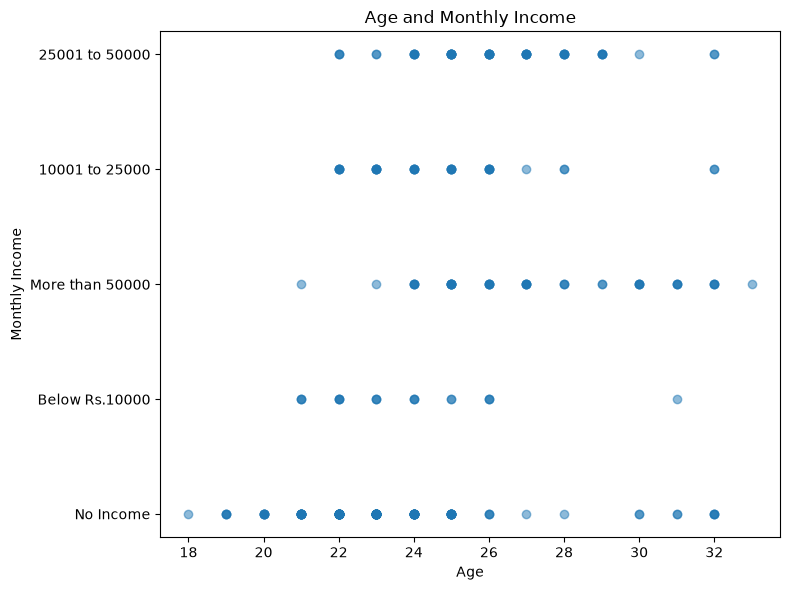

In [90]:
age vs odering 
plt.figure(figsize=(8,6))

plt.scatter(
    df["age"],
    df["monthly_income"],
    alpha=0.5
)

plt.title("Age and Monthly Income")
plt.xlabel("Age")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

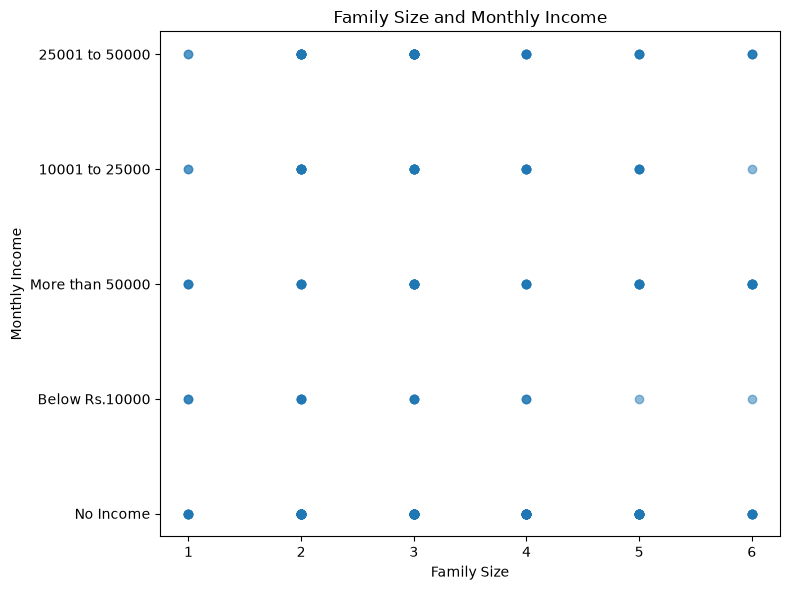

In [92]:
#family size vs odering 
plt.figure(figsize=(8,6))

plt.scatter(
    df["family_size"],
    df["monthly_income"],
    alpha=0.5
)

plt.title("Family Size and Monthly Income")
plt.xlabel("Family Size")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [94]:
#feedback
feedback_counts = df["feedback"].value_counts()

feedback_counts

feedback
Positive     231
Negative      54
Name: count, dtype: int64

In [95]:
feedback_percent = (
    df["feedback"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

feedback_percent

feedback
Positive     81.05
Negative     18.95
Name: proportion, dtype: float64

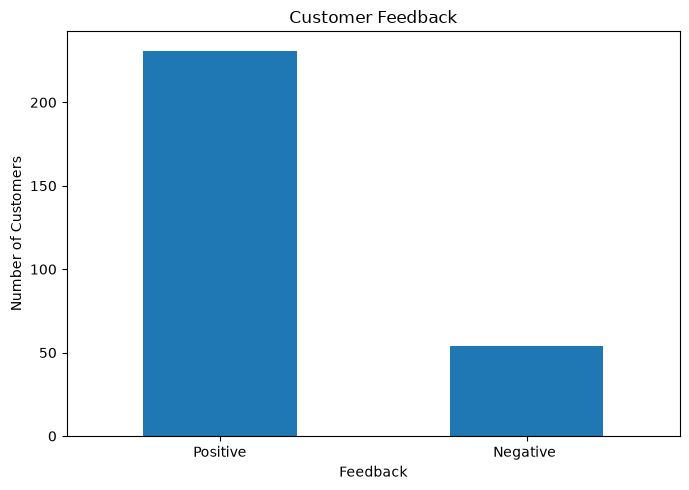

In [97]:
plt.figure(figsize=(7,5))

feedback_counts.plot(kind="bar")

plt.title("Customer Feedback")
plt.xlabel("Feedback")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [99]:
#feeback vs odering 
feedback_ordering = pd.crosstab(
    df["feedback"],
    df["output"],
    normalize="index"
).mul(100).round(2)

feedback_ordering

output,No,Yes
feedback,,
Negative,72.22,27.78
Positive,12.55,87.45


In [ ]:
#Geographic analysis

In [100]:
df[["latitude", "longitude"]].describe()

,latitude,longitude
count,285.000000,285.000000
mean,12.973429,77.597593
std,0.043964,0.053557
min,12.865200,77.484200
25%,12.943800,77.563500
50%,12.977000,77.587700
75%,12.998000,77.622700
max,13.102000,77.758200


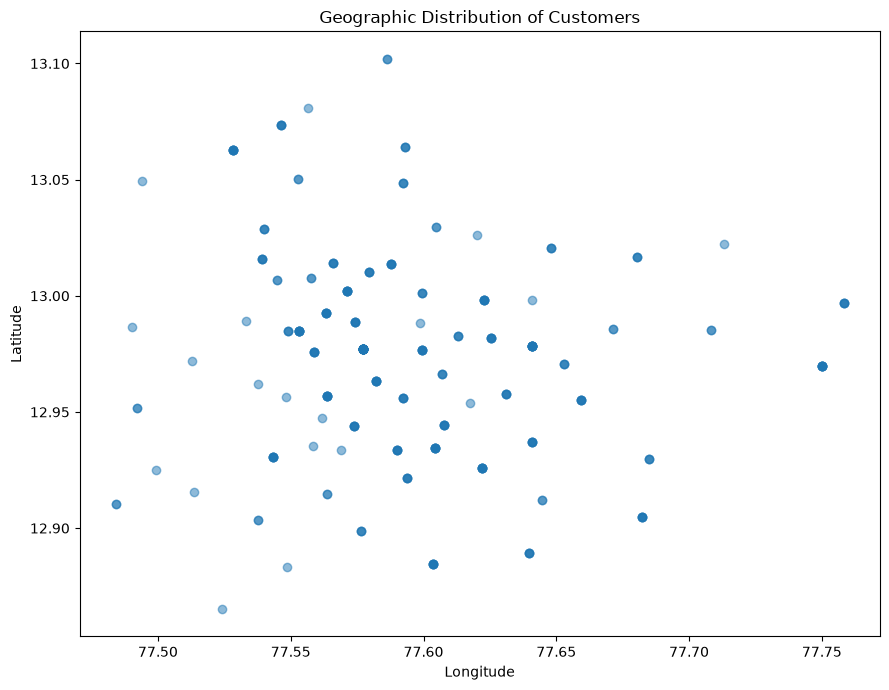

In [101]:
plt.figure(figsize=(9,7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.5
)

plt.title("Geographic Distribution of Customers")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

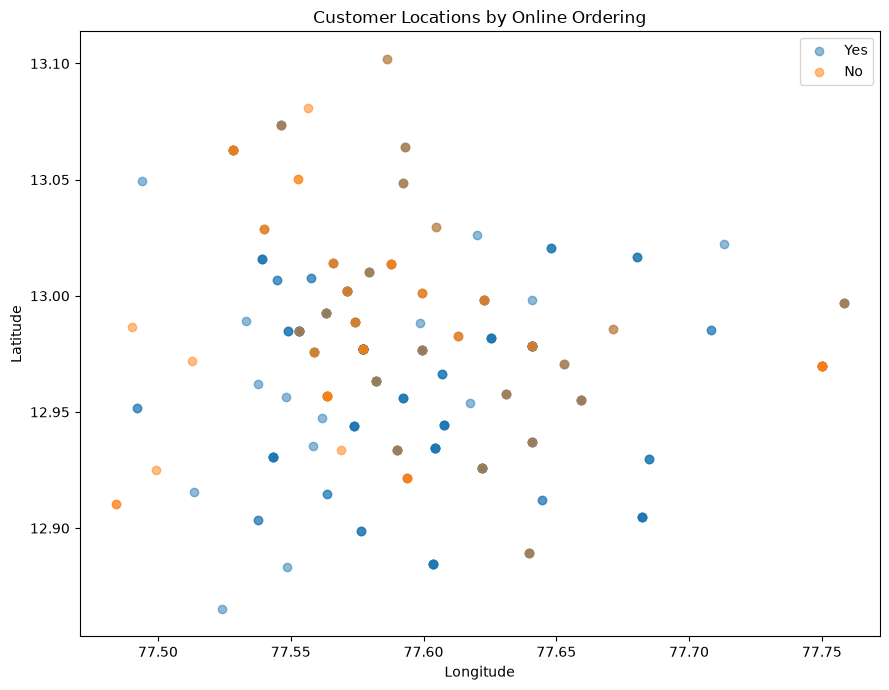

In [103]:
plt.figure(figsize=(9,7))

for category in df["output"].unique():

    subset = df[df["output"] == category]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        alpha=0.5,
        label=category
    )

plt.title("Customer Locations by Online Ordering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
Correlation analysis


In [106]:
numeric_columns = [
    "age",
    "monthly_income",
    "family_size",
    "latitude",
    "longitude"
]

In [112]:
numeric_columns = df.select_dtypes(include="number").columns
correlation = df[numeric_columns].corr()

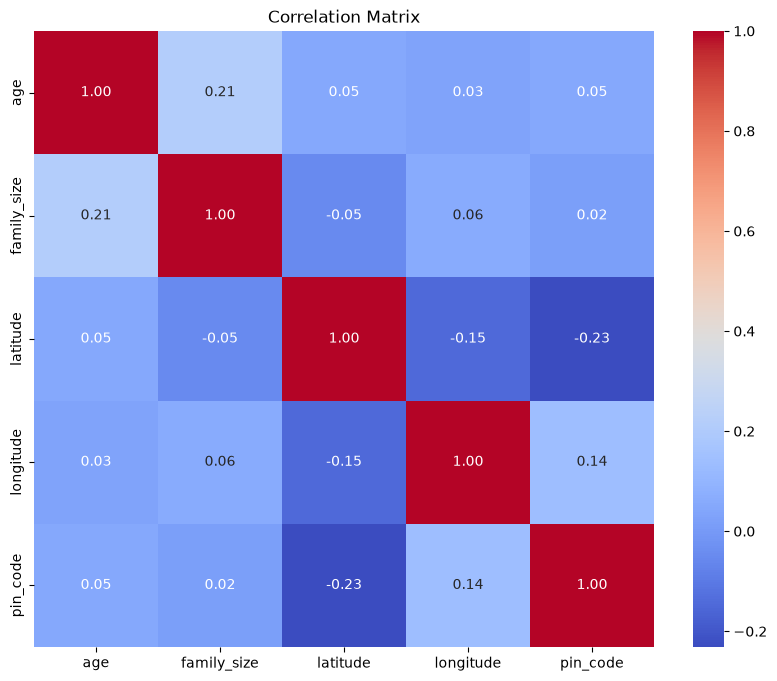

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [115]:
df["monthly_income"] = pd.to_numeric(df["monthly_income"], errors="coerce")

In [116]:
df["monthly_income"].isna().sum()

np.int64(285)

In [117]:
df["monthly_income"] = (
    df["monthly_income"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # strip anything that isn't a digit or decimal point
)
df["monthly_income"] = pd.to_numeric(df["monthly_income"], errors="coerce")

In [118]:
grouped = df.groupby("output")["monthly_income"]

income_comparison = pd.DataFrame({
    "count": grouped.count(),
    "mean": grouped.mean(),
    "median": grouped.median(),
    "min": grouped.min(),
    "max": grouped.max()
}).round(2)

income_comparison

,count,mean,median,min,max
output,,,,,
No,0,NaN,NaN,NaN,NaN
Yes,0,NaN,NaN,NaN,NaN


In [120]:
df["output"].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [121]:
#odering rate table 
ordering_summary = pd.DataFrame({
    "Gender": df.groupby("gender")["output"].apply(
        lambda x: (x == "Yes").mean() * 100
    )
})

ordering_summary

,Gender
gender,
Female,74.380165
Male,77.439024


In [122]:
#customer overall profile 
profile = {
    "Total customers": len(df),
    "Average age": df["age"].mean(),
    "Median age": df["age"].median(),
    "Average income": df["monthly_income"].mean(),
    "Median income": df["monthly_income"].median(),
    "Average family size": df["family_size"].mean()
}

profile

{'Total customers': 285,
 'Average age': np.float64(24.67719298245614),
 'Median age': np.float64(24.0),
 'Average income': nan,
 'Median income': np.float64(nan),
 'Average family size': np.float64(3.270175438596491)}

In [123]:
profile = {
    "Total customers": len(df),
    "Average age": round(df["age"].mean(), 2),
    "Median age": round(df["age"].median(), 2),
    "Average income": round(df["monthly_income"].mean(), 2),
    "Median income": round(df["monthly_income"].median(), 2),
    "Average family size": round(df["family_size"].mean(), 2)
}

profile

{'Total customers': 285,
 'Average age': np.float64(24.68),
 'Median age': np.float64(24.0),
 'Average income': nan,
 'Median income': np.float64(nan),
 'Average family size': np.float64(3.27)}

In [ ]:
The dataset contains 285 customers. The average customer age is approximately 24 years, while the median age is 24 years. This indicates a relatively young customer population.

In [124]:
import os

os.makedirs("results", exist_ok=True)

In [125]:
gender_ordering_percent.to_csv(
    "results/gender_ordering.csv"
)

age_ordering.to_csv(
    "results/age_ordering.csv"
)

occupation_ordering.to_csv(
    "results/occupation_ordering.csv"
)

income_comparison.to_csv(
    "results/income_comparison.csv"
)

feedback_ordering.to_csv(
    "results/feedback_ordering.csv"
)

In [127]:
import os
os.makedirs("visualizations", exist_ok=True)

<Figure size 900x600 with 0 Axes>

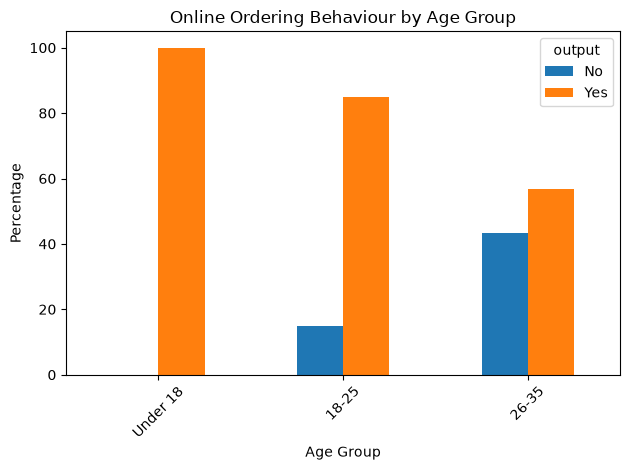

In [128]:
plt.figure(figsize=(9,6))

age_ordering.plot(kind="bar")

plt.title("Online Ordering Behaviour by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "visualizations/ordering_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [129]:
#Age finding
df["age_group"].value_counts().sort_index()

age_group
Under 18      1
18-25       194
26-35        90
36-45         0
46-55         0
56+           0
Name: count, dtype: int64

In [130]:
df["age_group"].value_counts().sort_index()

age_group
Under 18      1
18-25       194
26-35        90
36-45         0
46-55         0
56+           0
Name: count, dtype: int64

In [131]:
age_distribution = (
    df["age_group"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

age_distribution

age_group
Under 18     0.35
18-25       68.07
26-35       31.58
36-45        0.00
46-55        0.00
56+          0.00
Name: proportion, dtype: float64

In [132]:
age_distribution.idxmax()

'18-25'

In [133]:
age_distribution.max()

np.float64(68.07)

In [134]:
#key EDA findings 

1. Which occupation group has the largest representation?**
Students, by a wide margin — 144 out of 285 customers (50.5%), followed by Employees (94), Self Employed (38), and House wives (9).

2. Which gender has the higher online-ordering rate?**
Male customers order online slightly more often — 77.44% of males said "Yes" vs. 74.38% of females. The gap is small (~3 points), so gender isn't a strong differentiator here.


4. Age group representation — correction needed:
The 18-25 age group represents the largest share of customers,


5. Which age group has the highest online-ordering rate?
Under 18 is 100%, but that's just 1 person, so it's not statistically meaningful. Among the two substantial groups: **18-25 orders online at 85.05%**, compared to 56.67% for 26-35 — confirming stronger digital adoption among younger customers, which matches your written conclusion on this point.
6. Marital status vs ordering:
Single customers order online far more (84.66% Yes) than Married (60.92%) or "Prefer not to say" (44.44%).

7. Family size vs ordering:
Ordering rate isn't linear with family size — it peaks at family size 4 (86.67% Yes), and is lowest at family size 6 (60.87% Yes). Smaller/mid-size households order more than large ones.

8. Customer type vs ordering:
Fairly flat across groups — Regular (77.16%), Frequent (75.24%), New (72.22%). Customer type doesn't strongly predict ordering behavior.

9. Feedback vs ordering
This is the  strongest relationship — customers who gave **positive feedback ordered online 87.45%** of the time, vs. only **27.78%** for those who gave negative feedback. This suggests ordering experience and satisfaction are tightly linked (though correlation, not necessarily causation — could go either direction).


SyntaxError: invalid character '—' (U+2014) (3461352852.py, line 4)

In [135]:
df["output"].value_counts()

output
Yes    217
No      68
Name: count, dtype: int64

In [136]:
df["output"].value_counts()

output
Yes    217
No      68
Name: count, dtype: int64

In [ ]:
##7. Statistical Analysis

In [137]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [150]:
def chi_square_test(data, variable, target="output"):
    
    table = pd.crosstab(
        data[variable],
        data[target]
    )
    
    chi2, p, dof, expected = stats.chi2_contingency(table)
    
    return {
        "Variable": variable,
        "Chi-square": round(chi2, 4),
        "p-value": round(p, 4),
        "Degrees of freedom": dof,
        "Significant": "Yes" if p < 0.05 else "No"
    }

In [151]:
categorical_variables = [
    "gender",
    "age_group",
    "occupation",
    "educational_qualifications",
    "marital_status",
    "customer_type",
    "family_size",
    "feedback"
]

In [152]:
results = []

for variable in categorical_variables:
    results.append(
        chi_square_test(df, variable)
    )

chi_square_results = pd.DataFrame(results)

chi_square_results

,Variable,Chi-square,p-value,Degrees of freedom,Significant
0,gender,0.2100,0.6468,1,No
1,age_group,27.5804,0.0000,2,Yes
2,occupation,21.6089,0.0001,3,Yes
3,educational_qualifications,7.5164,0.1110,4,No
4,marital_status,23.6162,0.0000,2,Yes
5,customer_type,0.2920,0.8642,2,No
6,family_size,7.7697,0.1694,5,No
7,feedback,82.5231,0.0000,1,Yes


In [ ]:
#INCOME TEST

In [156]:
df_raw = pd.read_csv("online food delivery dataset.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(" ", "_")
df["monthly_income"] = df_raw["monthly_income"]

In [157]:
df["monthly_income"].unique()

<ArrowStringArray>
[      'No Income',  'Below Rs.10000', 'More than 50000',  '10001 to 25000',
  '25001 to 50000']
Length: 5, dtype: str

In [158]:
df.groupby("output")["monthly_income"].describe()

,count,unique,top,freq
output,,,,
No,68,5,No Income,19
Yes,217,5,No Income,112


In [163]:
income_mapping = {
    "No Income": 0,
    "Below Rs.10000": 5000,
    "10001 to 25000": 17500,
    "25001 to 50000": 37500,
    "More than 50000": 60000
}
df["monthly_income_numeric"] = df["monthly_income"].str.strip().map(income_mapping)

In [165]:
online_income = df[df["output"] == "Yes"]["monthly_income_numeric"].dropna()
offline_income = df[df["output"] == "No"]["monthly_income_numeric"].dropna()

print(len(online_income), len(offline_income))

217 68


In [166]:
stat, p = stats.mannwhitneyu(
    online_income,
    offline_income,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

Mann-Whitney U statistic: 5276.0
p-value: 0.0001724983847018139


In [ ]:
#Age test

In [167]:
online_age = df[
    df["output"] == "Yes"
]["age"]

offline_age = df[
    df["output"] == "No"
]["age"]

In [168]:
stat, p = stats.mannwhitneyu(
    online_age,
    offline_age,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

Mann-Whitney U statistic: 4754.5
p-value: 8.424062058553537e-06


In [ ]:
#statistical summary

In [169]:
statistical_summary = pd.DataFrame({
    "Variable": [
        "Gender",
        "Age Group",
        "Occupation",
        "Education",
        "Marital Status",
        "Customer Type",
        "Family Size",
        "Feedback",
        "Age",
        "Monthly Income"
    ],
    "Test": [
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Chi-square",
        "Mann-Whitney U",
        "Mann-Whitney U"
    ]
})

statistical_summary

,Variable,Test
0,Gender,Chi-square
1,Age Group,Chi-square
2,Occupation,Chi-square
3,Education,Chi-square
4,Marital Status,Chi-square
5,Customer Type,Chi-square
6,Family Size,Chi-square
7,Feedback,Chi-square
8,Age,Mann-Whitney U
9,Monthly Income,Mann-Whitney U


In [170]:
import os

os.makedirs("results", exist_ok=True)

In [171]:
chi_square_results.to_csv(
    "results/chi_square_tests.csv",
    index=False
)

In [ ]:
## Statistical Analysis

Chi-square tests were used to examine associations between online food ordering and categorical customer characteristics.

Mann-Whitney U tests were used to compare numerical variables between customers who ordered food online and those who did not.

A significance level of 0.05 was used.

In [ ]:
## Statistical Analysis Findings

The statistical analysis identified four customer characteristics with statistically significant associations with online food ordering: age group, occupation, marital status and customer feedback.

Customer feedback showed the strongest chi-square statistic among the categorical variables tested, with χ²(1) = 82.523 and p < 0.001. Age group also showed a strong association with ordering behaviour, χ²(2) = 27.580, p < 0.001.

Occupation was significantly associated with ordering behaviour, χ²(3) = 21.609, p < 0.001. Marital status also showed a statistically significant association, χ²(2) = 23.616, p < 0.001.

Gender, educational qualification, customer type and family size did not show statistically significant associations with online food ordering at the 5% significance level.

These results suggest that age, occupation, marital status and customer feedback are more useful variables for understanding differences in online ordering behaviour within this dataset.

In [ ]:
##9.SQL Analysis with DuckDB


In [172]:
pip install duckdb

   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
    --------------------------------------- 0.3/13.7 MB ? eta -:--:--
   -- ------------------------------------- 0.8/13.7 MB 1.8 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/13.7 MB 2.0 MB/s eta 0:00:07
   ---- ----------------------------------- 1.6/13.7 MB 1.9 MB/s eta 0:00:07
   ------ --------------------------------- 2.1/13.7 MB 2.0 MB/s eta 0:00:06
   ------- -------------------------------- 2.6/13.7 MB 2.0 MB/s eta 0:00:06
   --------- ------------------------------ 3.1/13.7 MB 2.1 MB/s eta 0:00:06
   ---------- ----------------------------- 3.7/13.7 MB 2.1 MB/s eta 0:00:05
   ------------ --------------------------- 4.2/13.7 MB 2.2 MB/s eta 0:00:05
   ------------- -------------------------- 4.7/13.7 MB 2.2 MB/s eta 0:00:05
   --------------- --------

In [173]:
import duckdb

In [174]:
con = duckdb.connect("restaurant_analysis.duckdb")

In [175]:
con.execute("""
CREATE OR REPLACE TABLE customers AS
SELECT *
FROM read_csv_auto('online_food_delivery_cleaned.csv')
""")

In [176]:
con.execute("""
SELECT *
FROM customers
LIMIT 10
""").df()

,age,gender,marital_status,occupation,monthly_income,educational_qualifications,family_size,customer_type,latitude,longitude,pin_code,output,feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,True,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,True,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,True,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,True,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,True,Positive
5,27,Female,Married,Employee,More than 50000,Post Graduate,2,Regular,12.9299,77.6848,560103,True,Positive
6,22,Male,Single,Student,No Income,Graduate,3,Regular,12.9770,77.5773,560009,True,Positive
7,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,560042,True,Positive
8,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,True,Positive
9,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,True,Positive


In [177]:
con.execute("""
SELECT COUNT(*) AS total_customers
FROM customers
""").df()

,total_customers
0,285


In [178]:
con.execute("""
DESCRIBE customers
""").df()

,column_name,column_type,null,key,default,extra
0,age,BIGINT,YES,None,None,None
1,gender,VARCHAR,YES,None,None,None
2,marital_status,VARCHAR,YES,None,None,None
3,occupation,VARCHAR,YES,None,None,None
4,monthly_income,VARCHAR,YES,None,None,None
5,educational_qualifications,VARCHAR,YES,None,None,None
6,family_size,BIGINT,YES,None,None,None
7,customer_type,VARCHAR,YES,None,None,None
8,latitude,DOUBLE,YES,None,None,None
9,longitude,DOUBLE,YES,None,None,None


In [179]:
con.execute("""
SELECT
    output,
    COUNT(*) AS customers
FROM customers
GROUP BY output
ORDER BY customers DESC
""").df()

,output,customers
0,True,217
1,False,68


In [180]:
#ordering percentages 
con.execute("""
SELECT
    output,
    COUNT(*) AS customers,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM customers
GROUP BY output
ORDER BY customers DESC
""").df()

,output,customers,percentage
0,True,217,76.14
1,False,68,23.86


In [182]:
# ordering by gender
con.execute("""
SELECT
    gender,
    output,
    COUNT(*) AS customers
FROM customers
GROUP BY gender, output
ORDER BY gender, customers DESC
""").df()


,gender,output,customers
0,Female,True,90
1,Female,False,31
2,Male,True,127
3,Male,False,37


In [183]:
con.execute("""
SELECT
    gender,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY gender
ORDER BY ordering_rate DESC
""").df()

,gender,ordering_rate
0,Male,77.44
1,Female,74.38


In [184]:
con.execute("""
SELECT
    CASE
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
        WHEN age BETWEEN 36 AND 45 THEN '36-45'
        WHEN age BETWEEN 46 AND 55 THEN '46-55'
        ELSE '56+'
    END AS age_group,

    COUNT(*) AS customers,

    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate

FROM customers

GROUP BY age_group

ORDER BY ordering_rate DESC
""").df()

,age_group,customers,ordering_rate
0,18-25,195,85.13
1,26-35,90,56.67


In [186]:
con.execute("""
SELECT
    CASE
        WHEN age < 18 THEN 'Under 18'
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
        WHEN age BETWEEN 36 AND 45 THEN '36-45'
        WHEN age BETWEEN 46 AND 55 THEN '46-55'
        ELSE '56+'
    END AS age_group,

    COUNT(*) AS customers,

    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate

FROM customers

GROUP BY age_group

ORDER BY ordering_rate DESC
""").df()

,age_group,customers,ordering_rate
0,18-25,195,85.13
1,26-35,90,56.67


In [187]:
con.execute("""
SELECT
    occupation,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY occupation
ORDER BY ordering_rate DESC
""").df()

,occupation,customers,ordering_rate
0,Student,144,87.50
1,House wife,9,77.78
2,Employee,94,63.83
3,Self Employeed,38,63.16


In [189]:
con.register("df", df)
con.execute("DROP TABLE IF EXISTS customers")
con.execute("CREATE TABLE customers AS SELECT * FROM df")

In [191]:
con.execute("""
SELECT
    output,
    COUNT(*) AS customers,
    ROUND(AVG(monthly_income_numeric), 2) AS average_income,
    ROUND(MEDIAN(monthly_income_numeric), 2) AS median_income
FROM customers
GROUP BY output
""").df()

,output,customers,average_income,median_income
0,Yes,217,16520.74,0.0
1,No,68,28088.24,37500.0


In [192]:
con.execute("""
SELECT
    family_size,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY family_size
ORDER BY family_size
""").df()

,family_size,customers,ordering_rate
0,1,18,72.22
1,2,75,73.33
2,3,87,80.46
3,4,45,86.67
4,5,37,70.27
5,6,23,60.87


In [193]:
con.execute("""
SELECT
    educational_qualifications,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY educational_qualifications
ORDER BY ordering_rate DESC
""").df()

,educational_qualifications,customers,ordering_rate
0,Post Graduate,125,83.20
1,School,11,81.82
2,Graduate,126,70.63
3,Ph.D,21,66.67
4,Uneducated,2,50.00


In [194]:
con.execute("""
SELECT
    marital_status,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY marital_status
ORDER BY ordering_rate DESC
""").df()

,marital_status,customers,ordering_rate
0,Single,189,84.66
1,Married,87,60.92
2,Prefer not to say,9,44.44


In [195]:
con.execute("""
SELECT
    customer_type,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY customer_type
ORDER BY ordering_rate DESC
""").df()

,customer_type,customers,ordering_rate
0,Regular,162,77.16
1,Frequent,105,75.24
2,New,18,72.22


In [196]:
con.execute("""
SELECT
    feedback,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY feedback
ORDER BY ordering_rate DESC
""").df()

,feedback,customers,ordering_rate
0,Positive,231,87.45
1,Negative,54,27.78


In [197]:
con.execute("""
SELECT
    occupation,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY occupation
HAVING COUNT(*) >= 5
ORDER BY ordering_rate DESC
""").df()

,occupation,customers,ordering_rate
0,Student,144,87.50
1,House wife,9,77.78
2,Employee,94,63.83
3,Self Employeed,38,63.16


In [198]:
con.execute("""
WITH occupation_analysis AS (

    SELECT
        occupation,
        COUNT(*) AS customers,
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END) AS online_customers

    FROM customers

    GROUP BY occupation
)

SELECT
    occupation,
    customers,
    online_customers,
    ROUND(
        online_customers * 100.0 / customers,
        2
    ) AS ordering_rate

FROM occupation_analysis

WHERE customers >= 5

ORDER BY ordering_rate DESC
""").df()

,occupation,customers,online_customers,ordering_rate
0,Student,144,126.0,87.50
1,House wife,9,7.0,77.78
2,Employee,94,60.0,63.83
3,Self Employeed,38,24.0,63.16


In [207]:
#customer segment 
con.execute("""
SELECT
    gender,
    customer_type,
    output,
    COUNT(*) AS customers
FROM customers
GROUP BY
    gender,
    customer_type,
    output
ORDER BY customers DESC
""").df()

,gender,customer_type,output,customers
0,Male,Regular,Yes,73
1,Female,Regular,Yes,52
2,Male,Frequent,Yes,45
3,Female,Frequent,Yes,34
4,Male,Regular,No,22
5,Female,Regular,No,15
6,Female,Frequent,No,14
7,Male,Frequent,No,12
8,Male,New,Yes,9
9,Female,New,Yes,4


In [200]:
import os

os.makedirs("results/sql", exist_ok=True)

In [202]:
sql_gender = con.execute("""
SELECT
    gender,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY gender
ORDER BY ordering_rate DESC
""").df()

In [204]:
sql_gender.to_csv(
    "results/sql/gender_ordering_sql.csv",
    index=False
)

In [ ]:
advancedc sql

In [208]:
import duckdb

con = duckdb.connect("restaurant_analysis.duckdb")

In [209]:
con.execute("""
SELECT COUNT(*) AS total_customers
FROM customers
""").df()

,total_customers
0,285


In [210]:
#Business Question 1: What percentage of customers order online?

con.execute("""
SELECT
    output,
    COUNT(*) AS customers,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM customers
GROUP BY output
ORDER BY customers DESC
""").df()

,output,customers,percentage
0,Yes,217,76.14
1,No,68,23.86


In [211]:
#Business Question 2: Which gender has the highest ordering rate?
con.execute("""
SELECT
    gender,
    COUNT(*) AS customers,
    SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END) AS online_customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY gender
ORDER BY ordering_rate DESC
""").df()

,gender,customers,online_customers,ordering_rate
0,Male,164,127.0,77.44
1,Female,121,90.0,74.38


In [212]:
#Business Question 3: Which age group orders online most?
con.execute("""
WITH age_groups AS (
    SELECT
        CASE
            WHEN age < 18 THEN 'Under 18'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            ELSE '56+'
        END AS age_group,
        output
    FROM customers
)

SELECT
    age_group,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM age_groups
GROUP BY age_group
ORDER BY ordering_rate DESC
""").df()

,age_group,customers,ordering_rate
0,18-25,195,85.13
1,26-35,90,56.67


In [213]:
#Business Question 4: Which occupation has the highest ordering rate?
con.execute("""
SELECT
    occupation,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY occupation
HAVING COUNT(*) >= 5
ORDER BY ordering_rate DESC
""").df()

,occupation,customers,ordering_rate
0,Student,144,87.50
1,House wife,9,77.78
2,Employee,94,63.83
3,Self Employeed,38,63.16


In [215]:
#Business Question 5: Does income differ between online and non-online customers?
con.execute("""
SELECT
    output,
    COUNT(*) AS customers,
    ROUND(AVG(monthly_income_numeric), 2) AS average_income,
    ROUND(MEDIAN(monthly_income_numeric), 2) AS median_income,
    ROUND(MIN(monthly_income_numeric), 2) AS minimum_income,
    ROUND(MAX(monthly_income_numeric), 2) AS maximum_income
FROM customers
GROUP BY output
ORDER BY average_income DESC
""").df() 

,output,customers,average_income,median_income,minimum_income,maximum_income
0,No,68,28088.24,37500.0,0,60000
1,Yes,217,16520.74,0.0,0,60000


In [216]:
#Business Question 6: Which family size has the highest ordering rate?
con.execute("""
SELECT
    family_size,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY family_size
HAVING COUNT(*) >= 5
ORDER BY ordering_rate DESC
""").df()

,family_size,customers,ordering_rate
0,4,45,86.67
1,3,87,80.46
2,2,75,73.33
3,1,18,72.22
4,5,37,70.27
5,6,23,60.87


In [217]:
#Business Question 7: Does education relate to ordering?
con.execute("""
SELECT
    educational_qualifications,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY educational_qualifications
ORDER BY ordering_rate DESC
""").df()

,educational_qualifications,customers,ordering_rate
0,Post Graduate,125,83.20
1,School,11,81.82
2,Graduate,126,70.63
3,Ph.D,21,66.67
4,Uneducated,2,50.00


In [218]:
#8: Which marital-status group orders most?
con.execute("""
SELECT
    marital_status,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY marital_status
ORDER BY ordering_rate DESC
""").df()

,marital_status,customers,ordering_rate
0,Single,189,84.66
1,Married,87,60.92
2,Prefer not to say,9,44.44


In [219]:
#9: Which customer type has the highest ordering rate?
con.execute("""
SELECT
    customer_type,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY customer_type
ORDER BY ordering_rate DESC
""").df()

,customer_type,customers,ordering_rate
0,Regular,162,77.16
1,Frequent,105,75.24
2,New,18,72.22


In [220]:
#10: Which feedback group orders most?
con.execute("""
SELECT
    feedback,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY feedback
ORDER BY ordering_rate DESC
""").df()

,feedback,customers,ordering_rate
0,Positive,231,87.45
1,Negative,54,27.78


In [221]:
#11: Which occupation contributes the most online customers?
con.execute("""
SELECT
    occupation,
    COUNT(*) AS online_customers
FROM customers
WHERE output = 'Yes'
GROUP BY occupation
ORDER BY online_customers DESC
""").df()

,occupation,online_customers
0,Student,126
1,Employee,60
2,Self Employeed,24
3,House wife,7


In [222]:
#12: Find the top customer segments
con.execute("""
SELECT
    gender,
    occupation,
    customer_type,
    COUNT(*) AS customers,
    SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END) AS online_customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY
    gender,
    occupation,
    customer_type
HAVING COUNT(*) >= 5
ORDER BY ordering_rate DESC
""").df()

,gender,occupation,customer_type,customers,online_customers,ordering_rate
0,Male,Student,New,5,5.0,100.00
1,Male,Student,Frequent,29,28.0,96.55
2,Female,Student,Frequent,19,17.0,89.47
3,Female,Student,Regular,36,32.0,88.89
4,Female,House wife,Frequent,7,6.0,85.71
5,Male,Employee,New,5,4.0,80.00
6,Male,Self Employeed,Regular,15,12.0,80.00
7,Male,Student,Regular,51,40.0,78.43
8,Male,Employee,Regular,29,21.0,72.41
9,Female,Self Employeed,Regular,7,5.0,71.43


In [223]:
#13: Rank occupations using a window function
con.execute("""
WITH occupation_rates AS (

    SELECT
        occupation,
        COUNT(*) AS customers,
        ROUND(
            SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*),
            2
        ) AS ordering_rate

    FROM customers

    GROUP BY occupation

    HAVING COUNT(*) >= 5
)

SELECT
    occupation,
    customers,
    ordering_rate,

    RANK() OVER (
        ORDER BY ordering_rate DESC
    ) AS ranking

FROM occupation_rates

ORDER BY ranking
""").df()

,occupation,customers,ordering_rate,ranking
0,Student,144,87.50,1
1,House wife,9,77.78,2
2,Employee,94,63.83,3
3,Self Employeed,38,63.16,4


In [224]:
#14: Rank age groups
con.execute("""
WITH age_groups AS (

    SELECT
        CASE
            WHEN age < 18 THEN 'Under 18'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            ELSE '56+'
        END AS age_group,
        output

    FROM customers
),

age_rates AS (

    SELECT
        age_group,
        COUNT(*) AS customers,
        ROUND(
            SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*),
            2
        ) AS ordering_rate

    FROM age_groups

    GROUP BY age_group
)

SELECT
    age_group,
    customers,
    ordering_rate,

    RANK() OVER (
        ORDER BY ordering_rate DESC
    ) AS ranking

FROM age_rates

ORDER BY ranking
""").df()

,age_group,customers,ordering_rate,ranking
0,18-25,195,85.13,1
1,26-35,90,56.67,2


In [225]:
#15: Compare each occupation with the overall ordering rate
con.execute("""
WITH overall AS (

    SELECT
        ROUND(
            SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*),
            2
        ) AS overall_rate

    FROM customers
),

occupation_rates AS (

    SELECT
        occupation,
        COUNT(*) AS customers,

        ROUND(
            SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*),
            2
        ) AS ordering_rate

    FROM customers

    GROUP BY occupation

    HAVING COUNT(*) >= 5
)

SELECT
    o.occupation,
    o.customers,
    o.ordering_rate,
    overall.overall_rate,

    ROUND(
        o.ordering_rate - overall.overall_rate,
        2
    ) AS difference_from_overall

FROM occupation_rates o
CROSS JOIN overall

ORDER BY difference_from_overall DESC
""").df()

,occupation,customers,ordering_rate,overall_rate,difference_from_overall
0,Student,144,87.50,76.14,11.36
1,House wife,9,77.78,76.14,1.64
2,Employee,94,63.83,76.14,-12.31
3,Self Employeed,38,63.16,76.14,-12.98


In [226]:
top_occupations = con.execute("""
SELECT
    occupation,
    COUNT(*) AS customers,
    ROUND(
        SUM(CASE WHEN output = 'Yes' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS ordering_rate
FROM customers
GROUP BY occupation
HAVING COUNT(*) >= 5
ORDER BY ordering_rate DESC
""").df()

In [227]:
top_occupations.to_csv(
    "results/sql/top_occupations.csv",
    index=False
)

In [ ]:
## Business Questions

1. What percentage of customers order food online?

2. Which gender has the highest ordering rate?

3. Which age group has the highest ordering rate?

4. Which occupation has the highest ordering rate?

5. Does monthly income differ between online and non-online customers?

6. Which family size has the highest ordering rate?

7. Does educational qualification relate to ordering behaviour?

8. Which marital-status group has the highest ordering rate?

9. Which customer type has the highest ordering rate?

10. Which feedback group has the highest ordering rate?

11. Which occupation contributes the most online customers?

12. Which demographic segments have the highest ordering rates?

13. How do occupations rank by ordering rate?

14. How do age groups rank by ordering rate?

15. Which occupations perform above the overall ordering rate?

In [ ]:
##10. VISUALIZATION

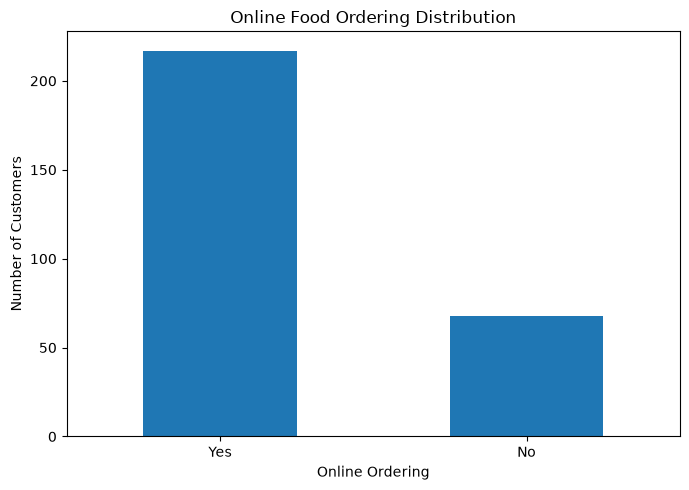

In [228]:
import matplotlib.pyplot as plt

df["output"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Online Food Ordering Distribution")
plt.xlabel("Online Ordering")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

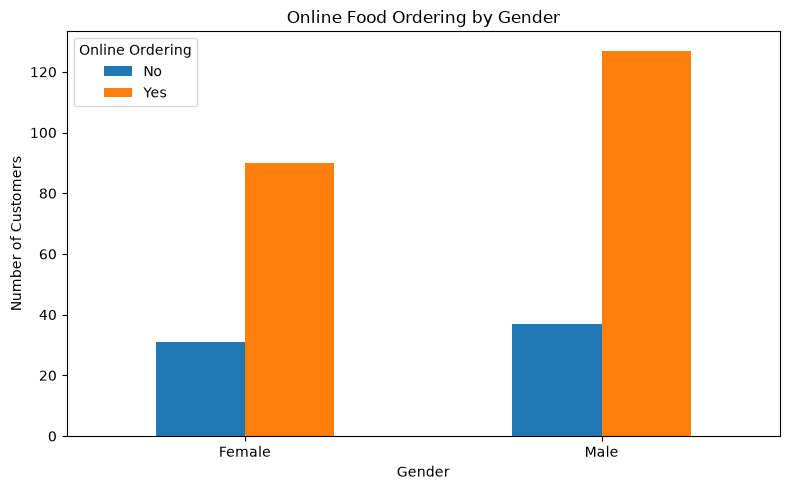

In [229]:
pd.crosstab(
    df["gender"],
    df["output"]
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Food Ordering by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Online Ordering")
plt.tight_layout()
plt.show()

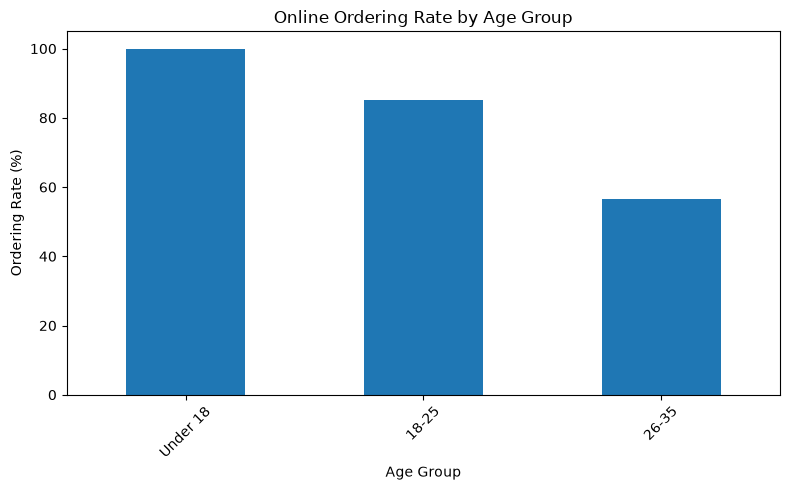

In [230]:
age_ordering = pd.crosstab(
    df["age_group"],
    df["output"],
    normalize="index"
) * 100

age_ordering["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Ordering Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Ordering Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

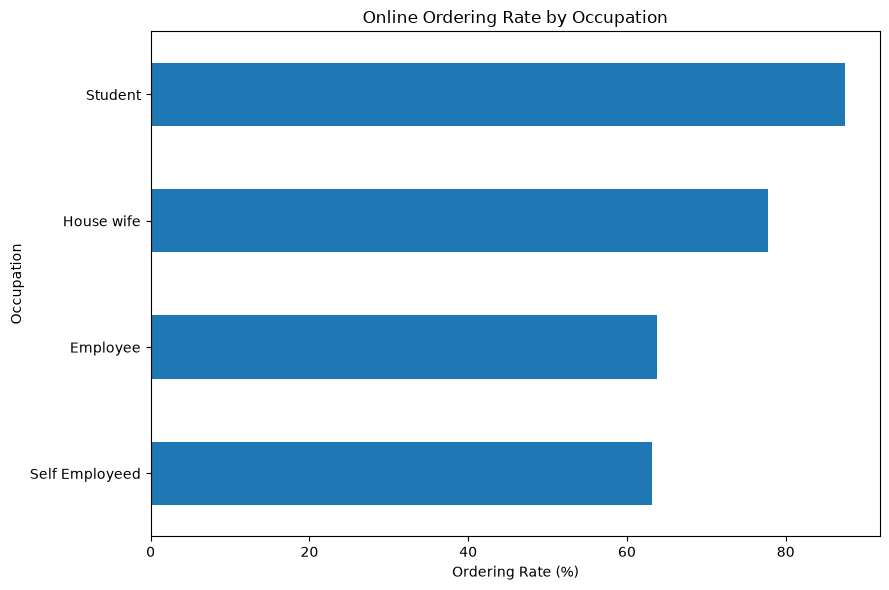

In [231]:
occupation_ordering = pd.crosstab(
    df["occupation"],
    df["output"],
    normalize="index"
) * 100

occupation_ordering["Yes"].sort_values().plot(
    kind="barh",
    figsize=(9,6)
)

plt.title("Online Ordering Rate by Occupation")
plt.xlabel("Ordering Rate (%)")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

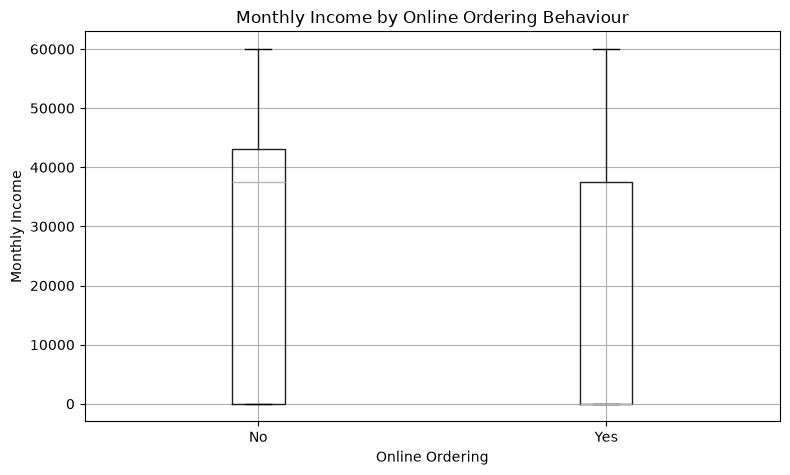

In [233]:
df.boxplot(
    column="monthly_income_numeric",
    by="output",
    figsize=(8,5)
)
plt.title("Monthly Income by Online Ordering Behaviour")
plt.suptitle("")
plt.xlabel("Online Ordering")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

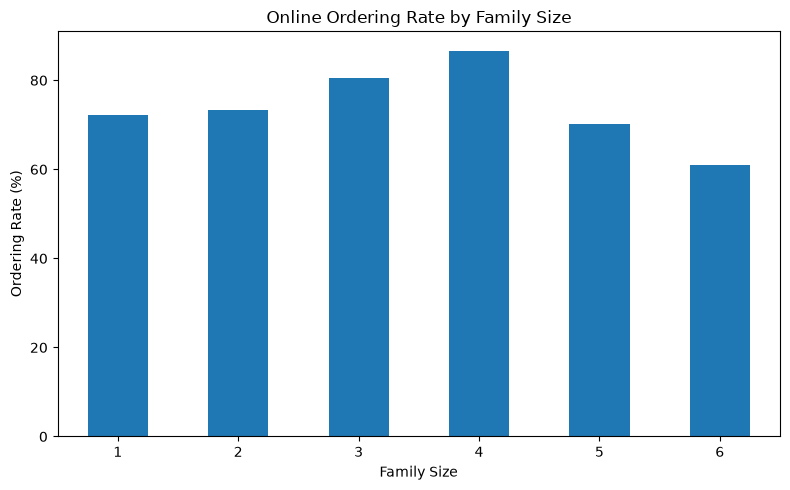

In [234]:
family_ordering = pd.crosstab(
    df["family_size"],
    df["output"],
    normalize="index"
) * 100

family_ordering["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Ordering Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Ordering Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

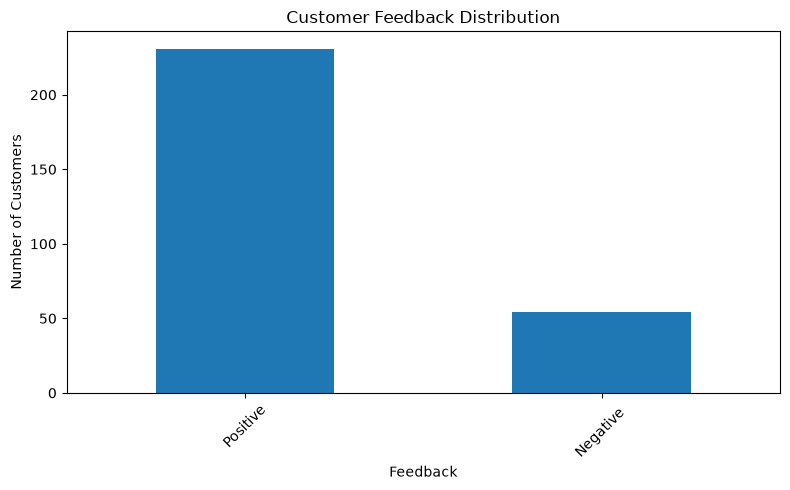

In [235]:
df["feedback"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Feedback Distribution")
plt.xlabel("Feedback")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

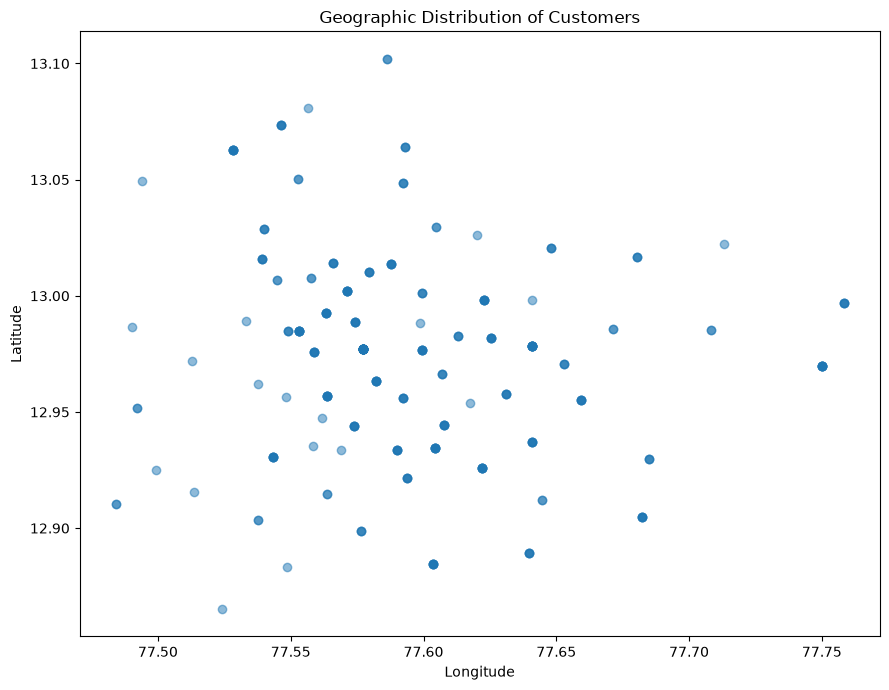

In [236]:
plt.figure(figsize=(9,7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.5
)

plt.title("Geographic Distribution of Customers")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [ ]:
## 7. Key Visual Findings

### Overall Ordering Behaviour

Approximately 76% of customers in the dataset order food online, while approximately 24% do not. This indicates a strong level of online food-delivery adoption within the sample.

### Gender

Online ordering rates are similar for females and males. Females have an ordering rate of approximately 74%, compared with approximately 77% for males. Gender therefore shows a relatively small difference in ordering behaviour.

### Age

Ordering rates differ substantially across age groups. Customers aged 18-25 show an ordering rate of approximately 85%, compared with approximately 57% among customers aged 26-35. The under-18 category records 100%, but this group contains only one customer and should not be treated as representative.

### Occupation

Students have the highest online-ordering rate at approximately 87%. House wives follow at approximately 78%, while Employees and Self Employed customers record rates of approximately 64% and 63%, respectively.

### Monthly Income

Monthly income shows substantial overlap between customers who order online and those who do not. The income distributions therefore do not show a strong visual separation between the two groups.

### Family Size

Ordering behaviour varies across family sizes. Customers with a family size of four show the highest ordering rate at approximately 87%. Ordering rates decline among larger family sizes, reaching approximately 61% for family size six.

### Customer Feedback

Feedback shows the largest observed difference in ordering behaviour. Positive-feedback customers have an online-ordering rate of approximately 87%, compared with approximately 28% among negative-feedback customers.

### Geographic Distribution

The latitude and longitude visualization does not show an obvious geographic concentration of customers. Geographic location therefore does not appear to show a strong pattern from visual inspection alone.

In [ ]:
## 11. Business Recommendations

The analysis identified age group, occupation, marital status and customer feedback as statistically significant factors associated with online food ordering. Based on these findings, the following recommendations are proposed.

### 1. Focus digital marketing on younger customers

Customers aged 18-25 showed a substantially higher online-ordering rate than older groups.

Restaurants and food-delivery platforms should prioritize digital campaigns aimed at younger customers. Suitable channels include social media, mobile promotions, student-focused campaigns and referral programs.

### 2. Develop student-focused offers

Students recorded the highest ordering rate among the occupational groups.

Restaurants should consider student meal packages, affordable combo meals, delivery promotions and time-limited digital offers aimed at students.

### 3. Prioritize customer satisfaction

Feedback showed the strongest statistical association with online ordering.

Businesses should monitor customer feedback closely and respond to negative experiences quickly. Important areas include food quality, delivery time, order accuracy, packaging and customer service.

### 4. Investigate negative feedback

Customers providing negative feedback showed a substantially lower online-ordering rate.

Businesses should identify the main reasons behind negative feedback and address recurring problems. A structured feedback system would help identify operational weaknesses.

### 5. Segment marketing by occupation

Occupation showed a statistically significant association with online ordering.

Marketing strategies should therefore consider occupational differences. Student-focused offers, employee lunch packages and convenient meal options for working customers are possible approaches.

### 6. Consider marital-status differences

Marital status also showed a statistically significant association with online ordering.

Restaurants should examine ordering patterns across marital-status groups and develop offers suited to different household and lifestyle needs.

### 7. Do not rely heavily on gender-based targeting

Gender did not show a statistically significant association with online ordering.

Marketing decisions should therefore avoid assuming that one gender is substantially more likely to order online than another based on this dataset.

### 8. Do not treat education as a primary segmentation variable

Educational qualification did not show a statistically significant association with online ordering.

Businesses should prioritize stronger variables such as age, occupation and customer feedback when designing customer segments.

### 9. Do not assume larger families order less

Family size did not show a statistically significant association with online ordering despite visible differences in the descriptive analysis.

Businesses should therefore avoid making strong decisions based on family size alone.

### 10. Use customer data for targeted marketing

The analysis demonstrates the value of combining demographic, behavioural and feedback data.

A restaurant or food-delivery business should develop customer segments using variables supported by the analysis, especially age, occupation, marital status and feedback.

### Recommended Priority

Based on the statistical results, the recommended priority order is:

1. Customer feedback and satisfaction
2. Age group
3. Occupation
4. Marital status
5. Gender
6. Education
7. Customer type
8. Family size

The first four variables showed statistically significant associations with online food ordering. The remaining variables did not show statistically significant associations at the 5% significance level.

In [ ]:
## 12. Final Conclusion

This project analysed customer behaviour in an online food delivery dataset using Python, statistical analysis and SQL.

The analysis began with data inspection and cleaning, followed by exploratory data analysis and visualization. Statistical tests were then used to examine whether customer characteristics were associated with online food ordering.

Approximately 76% of customers in the dataset reported ordering food online, indicating a high level of online food delivery adoption within the sample.

The statistical analysis identified four variables with significant associations with online food ordering: age group, occupation, marital status and customer feedback.

Age group showed a significant association with ordering behaviour, with younger customers generally showing higher ordering rates. Occupation also showed significant differences, with students recording the highest ordering rate among the occupational groups analysed.

Marital status showed a statistically significant association with online ordering. Customer feedback produced the strongest chi-square result among the categorical variables tested, indicating a strong relationship between feedback and ordering behaviour within the dataset.

Gender, educational qualifications, customer type and family size did not show statistically significant associations with online food ordering.

The analysis also showed substantial overlap in monthly income between customers who ordered online and those who did not. Geographic visualization did not reveal an obvious concentration of customers based on latitude and longitude.

Overall, the findings suggest that customer satisfaction, age, occupation and marital status provide more useful segmentation variables for understanding online food ordering behaviour in this dataset than gender, education, customer type or family size.

From a business perspective, food delivery businesses should pay particular attention to customer satisfaction, younger customer segments and occupational groups with higher ordering rates. Businesses should also use customer feedback to identify service problems and improve the customer experience.

This analysis demonstrates how Python, SQL, exploratory data analysis, visualization and statistical testing can be combined to transform raw customer data into actionable business insights.

The findings describe associations within the available dataset and should not be interpreted as evidence of causal relationships.bbbb

In [ ]:
## Key Findings

The analysis identified four variables with statistically significant associations with online food ordering:

- Age group
- Occupation
- Marital status
- Customer feedback

Gender, educational qualifications, customer type and family size did not show statistically significant associations with online food ordering at the 5% significance level.

Customer feedback produced the strongest chi-square statistic among the categorical variables tested.

Younger customers and students showed higher online-ordering rates in the descriptive analysis.

Approximately 76% of customers in the dataset reported ordering food online.